# 6G Indoor Radio Map: GCN/GAT vs. IDW/Kriging Sweep

Built from RadioGAT-inspired scaffolding, adapted to the **DeepMIMO** indoor mmWave ray-tracing dataset.

Pipeline:
1. Install dependencies
2. Load an indoor DeepMIMO scenario (point cloud + RSS + environment features)
3. Build k-NN / Delaunay graphs
4. Define GCN and GAT models
5. Define IDW and Kriging baselines
6. Run a dense/sparse x topology x model sweep

**Before running the full sweep:** run the "list indoor scenarios" cell first, inspect the printed names, and set `SCENARIO_NAME` to a real one — the online catalog changes over time, so nothing is hardcoded.


## 1. Setup

In [1]:
import sys
print(sys.executable)

from datetime import datetime
print(datetime.now())

/home/praaneshnair/random/prism/.venv/bin/python
2026-09-14 14:14:35.620115


In [2]:
import sys

!uv pip install --python {sys.executable} deepmimo torch torch_geometric scikit-learn scipy matplotlib pykrige pandas


Audited 8 packages in 59ms


## 2. Data loading — DeepMIMO indoor scenario

Loads an indoor DeepMIMO scenario and turns it into the point-cloud format the rest of
the pipeline (graph construction, GCN/GAT, baselines) expects:

- `positions`: `(N, 3)` array of rx `(x, y, z)`
- `rss`: `(N,)` received power in dBm for one tx
- `env_feats`: `(N, F)` per-point environment features (LOS flag, distance to tx, etc.)


In [3]:
import numpy as np
import deepmimo as dm

def list_indoor_scenarios():
    """Search the live DeepMIMO catalog for indoor scenarios. Run this first
    and pick a name from the printed list -- don't hardcode a slug, the
    catalog changes."""
    results = dm.search({"environment": "indoor"})
    for r in results:
        print(r)
    return results

def load_scenario(scenario_name: str, tx_index: int = 0, max_points: int | None = 5000, seed: int = 0):
    dm.download(scenario_name)

    # Find the rx set and its total point count from the cheap params file,
    # WITHOUT loading any ray-tracing data yet.
    txrx_sets = dm.get_txrx_sets(scenario_name)
    rx_set = next(s for s in txrx_sets if s.is_rx and not s.is_tx)  # adjust if there are multiple pure-rx sets
    n_points = rx_set.num_points

    if max_points is not None and n_points > max_points:
        rng = np.random.default_rng(seed)
        keep = np.sort(rng.choice(n_points, size=max_points, replace=False))
        rx_sets_param = {rx_set.id: keep}
        print(f"Subsampled {scenario_name}: {n_points} -> {max_points} rx points (at load time).")
    else:
        rx_sets_param = "rx_only"
        keep = np.arange(n_points)

    # Only THESE rx points' ray data is ever read from disk.
    dataset = dm.load(scenario_name, rx_sets=rx_sets_param)

    # dm.load() returns a MacroDataset -- a list-like wrapper holding one
    # Dataset per active transmitter -- whenever the scenario has more than
    # one tx (e.g. "i1_2p5"). `tx_index` is meant to pick WHICH transmitter to
    # build the radio map for, so select it here, before touching anything
    # else. Scenarios with a single tx (e.g. "i2_28b") already get a plain
    # Dataset back from dm.load(), so there's nothing to select in that case --
    # this is why the bug didn't show up until a multi-tx scenario was used.
    if isinstance(dataset, dm.MacroDataset):
        dataset = dataset.datasets[tx_index]

    positions = np.asarray(dataset.rx_pos)
    channels = dataset.compute_channels()  # [n_users, n_rx_ant, n_tx_ant, n_paths]
    # Average received power over rx antennas, tx antennas, and paths.
    power_lin = np.mean(np.abs(channels) ** 2, axis=(1, 2, 3))
    rss_dbm = 10 * np.log10(power_lin + 1e-15)

    tx_pos = np.asarray(dataset.tx_pos).reshape(-1)[:3]
    dist_to_tx = np.linalg.norm(positions - tx_pos, axis=1)
    los_flag = np.asarray(dataset.los).astype(float) if hasattr(dataset, "los") else np.ones(len(positions))
    env_feats = np.stack([dist_to_tx, los_flag], axis=1)

    return positions, rss_dbm, env_feats

### 2a. List live indoor scenarios (run this first)

In [4]:
list_indoor_scenarios()


i1_2p5
i2_28b


['i1_2p5', 'i2_28b']

### 2b. Pick a scenario name from the list above, then load it

In [5]:
SCENARIO_NAME = "i2_28b"

pos, rss, feats = load_scenario(SCENARIO_NAME)
print(pos.shape, rss.shape, feats.shape)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.09it/s]

(5000, 3) (5000,) (5000, 2)


In [6]:
def normalize_features(positions, feats, rss):
    pos_mean, pos_std = positions.mean(0), positions.std(0) + 1e-8
    feats_mean, feats_std = feats.mean(0), feats.std(0) + 1e-8
    rss_mean, rss_std = rss.mean(), rss.std() + 1e-8

    positions_n = (positions - pos_mean) / pos_std
    feats_n = (feats - feats_mean) / feats_std
    rss_n = (rss - rss_mean) / rss_std

    stats = {"rss_mean": rss_mean, "rss_std": rss_std}
    return positions_n, feats_n, rss_n, stats

pos, feats, rss_norm, norm_stats = normalize_features(pos, feats, rss)

## 3. Graph construction — k-NN and Delaunay

Two interchangeable edge-construction functions, both returning an `edge_index`
of shape `(2, num_edges)` in the format `torch_geometric` expects.


In [7]:
from scipy.spatial import Delaunay
from sklearn.neighbors import kneighbors_graph

def knn_graph(positions: np.ndarray, k: int = 6):
    adj = kneighbors_graph(positions, n_neighbors=k, mode="connectivity", include_self=False)
    adj = adj.maximum(adj.T)  # symmetrize
    coo = adj.tocoo()
    edge_index = np.vstack([coo.row, coo.col])
    return edge_index

def delaunay_graph(positions: np.ndarray):
    # Delaunay works on the 2D (x, y) footprint; z is usually near-constant per floor
    tri = Delaunay(positions[:, :2])
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = np.array(list(edges)).T
    return edge_index

BUILDERS = {"knn": knn_graph, "delaunay": delaunay_graph}


## 4. Models — GCN and GAT

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3):
        super().__init__()
        dims = [in_channels] + [hidden] * (layers - 1) + [out_channels]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x

class GAT(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, concat=True))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, concat=True))
        self.convs.append(GATConv(hidden * heads, out_channels, heads=1, concat=False))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return x


/home/praaneshnair/random/prism/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 5. Baselines — IDW and Kriging

In [9]:
from pykrige.ok import OrdinaryKriging

def idw_predict(train_pos, train_val, test_pos, power=2, eps=1e-9):
    preds = np.zeros(len(test_pos))
    for i, p in enumerate(test_pos):
        d = np.linalg.norm(train_pos - p, axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * train_val) / np.sum(w)
    return preds

def kriging_predict(train_pos, train_val, test_pos):
    ok = OrdinaryKriging(train_pos[:, 0], train_pos[:, 1], train_val, variogram_model="spherical")
    preds, _ = ok.execute("points", test_pos[:, 0], test_pos[:, 1])
    return np.asarray(preds)


## 6. Training loop + dense/sparse x topology x model sweep

Runs GCN and GAT over both graph topologies, plus IDW and Kriging baselines,
across a set of labeled-point densities (e.g. sparse 30-50 pts vs. dense 200+ pts).


In [10]:
from sklearn.metrics import mean_squared_error

def make_split(n_points, n_labeled, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n_points)
    return idx[:n_labeled], idx[n_labeled:]

def run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx, epochs=200, lr=0.005, device="cpu"):
    x = torch.tensor(np.hstack([positions, feats]), dtype=torch.float32).to(device)
    y = torch.tensor(rss, dtype=torch.float32).unsqueeze(1).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)
    mask = torch.zeros(len(rss), dtype=torch.bool)
    mask[train_idx] = True
    mask = mask.to(device)

    model = model_cls(in_channels=x.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(x, ei)
        loss = loss_fn(out[mask], y[mask])
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(x, ei).cpu().numpy().squeeze()
    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred[test_idx])))
    return rmse

def sweep(scenario_name, densities=(30, 50, 200), topologies=("knn", "delaunay")):
    positions, rss, feats = load_scenario(scenario_name)
    results = []

    for n_labeled in densities:
        train_idx, test_idx = make_split(len(positions), n_labeled)

        for topo in topologies:
            edge_index = BUILDERS[topo](positions)

            for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                rmse = run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx)
                results.append({"density": n_labeled, "topology": topo, "model": name, "rmse": rmse})

        idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred)))})

        krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "Kriging",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred)))})

    return results


### 6a. Run the sweep

Uses the `SCENARIO_NAME` you set in cell 2b.

In [11]:
results = sweep(SCENARIO_NAME)
for row in results:
    print(row)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.64it/s]


{'density': 30, 'topology': 'knn', 'model': 'GCN', 'rmse': 9.955528555939408}
{'density': 30, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.347684107825732}
{'density': 30, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 12.190210911441593}
{'density': 30, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 4.413883171827389}
{'density': 30, 'topology': '-', 'model': 'IDW', 'rmse': 4.290046006831081}
{'density': 30, 'topology': '-', 'model': 'Kriging', 'rmse': 4.2486775324974015}
{'density': 50, 'topology': 'knn', 'model': 'GCN', 'rmse': 11.389846000668548}
{'density': 50, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.287023507824586}
{'density': 50, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 11.85952038983673}
{'density': 50, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 4.281782131120615}
{'density': 50, 'topology': '-', 'model': 'IDW', 'rmse': 3.9568066118370107}
{'density': 50, 'topology': '-', 'model': 'Kriging', 'rmse': 4.103846062034357}
{'density': 200, 'topology': 'knn', 'mod

### 6b. (Optional) Tabulate and plot results

,density,topology,model,rmse
0,30,knn,GCN,9.955529
1,30,knn,GAT,4.347684
2,30,delaunay,GCN,12.190211
3,30,delaunay,GAT,4.413883
4,30,-,IDW,4.290046
5,30,-,Kriging,4.248678
6,50,knn,GCN,11.389846
7,50,knn,GAT,4.287024
8,50,delaunay,GCN,11.859520
9,50,delaunay,GAT,4.281782


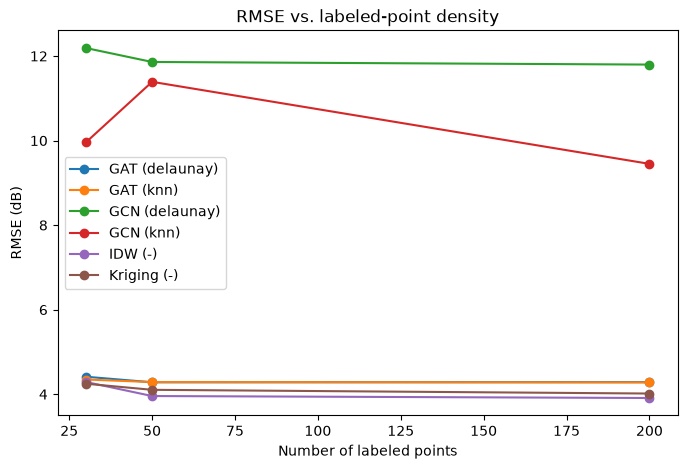

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(8, 5))
for (model, topo), grp in df.groupby(["model", "topology"]):
    grp = grp.sort_values("density")
    ax.plot(grp["density"], grp["rmse"], marker="o", label=f"{model} ({topo})")
ax.set_xlabel("Number of labeled points")
ax.set_ylabel("RMSE (dB)")
ax.set_title("RMSE vs. labeled-point density")
ax.legend()
plt.show()


## 7. Generalization across indoor layouts

Train on one scenario, zero-shot evaluate on a different (unseen) layout.

The below code is for downloading/re-downloading i1_2p5

In [13]:
import json, numpy as np, scipy.io, pprint

SCEN_FOLDER = "/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5"

with open(f"{SCEN_FOLDER}/objects.json") as f:
    objects_metadata = json.load(f)

print("=== objects.json (full) ===")
pprint.pprint(objects_metadata)

vertices = scipy.io.loadmat(f"{SCEN_FOLDER}/vertices.mat", squeeze_me=True)
faces_mat = scipy.io.loadmat(f"{SCEN_FOLDER}/faces.mat", squeeze_me=True)
mats_mat = scipy.io.loadmat(f"{SCEN_FOLDER}/materials.mat", squeeze_me=True)

print("\n=== vertices.mat ===")
for k, v in vertices.items():
    if not k.startswith("__"):
        print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))
print(vertices.get("vertices"))

print("\n=== faces.mat['faces'] ===")
f_arr = faces_mat["faces"]
print(type(f_arr), getattr(f_arr, "shape", None), getattr(f_arr, "dtype", None))
print(f_arr)

print("\n=== materials.mat['materials'] ===")
m_arr = mats_mat["materials"]
print(type(m_arr), getattr(m_arr, "shape", None), getattr(m_arr, "dtype", None))
print(m_arr)

=== objects.json (full) ===
[{'faces': [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9], [10, 11]],
  'id': 0,
  'label': 'floorplans'},
 {'faces': [[12], [13], [14, 15], [16, 17], [18, 19]],
  'id': 2,
  'label': 'floorplans'},
 {'faces': [[20, 21, 22],
            [23, 24, 25],
            [26, 27],
            [28, 29],
            [30, 31],
            [32, 33],
            [34, 35]],
  'id': 4,
  'label': 'floorplans'}]

=== vertices.mat ===
vertices <class 'numpy.ndarray'> (19, 3) float32
[[-15.970854   19.86909     0.       ]
 [-15.970188   13.451146    0.       ]
 [-15.969827    9.9656105   0.       ]
 [-15.9705     16.451145    0.       ]
 [-15.970854   19.86909     5.       ]
 [-15.970188   13.451146    5.       ]
 [-15.969827    9.9656105   5.       ]
 [-15.9705     16.451145    5.       ]
 [-26.061207    9.9656105   0.       ]
 [-23.989946   20.056992    0.       ]
 [-26.061207   20.056992    0.       ]
 [-26.061207    9.9656105   5.       ]
 [-23.989946   20.056992    5.       ]
 [

In [14]:
import shutil, json, os
import numpy as np
import scipy.io
import deepmimo as dm
from deepmimo.core.scene import Scene, PhysicalElement, Face

SCEN_FOLDER = "/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5"

shutil.rmtree(SCEN_FOLDER, ignore_errors=True)
dm.download("i1_2p5")

def _build_scene_from_legacy_triangulated_hull(base_folder):
    """Reconstruct a Scene for the older schema where objects.json groups
    row-indices into an already-triangulated faces.mat / materials.mat pair,
    instead of the 'face_vertex_idxs' or 'mesh_key' formats this deepmimo
    version's Scene.from_data() knows how to parse."""
    with open(f"{base_folder}/objects.json") as f:
        objects_metadata = json.load(f)

    vertices = scipy.io.loadmat(f"{base_folder}/vertices.mat", squeeze_me=True)["vertices"]
    tri_vertex_idxs = scipy.io.loadmat(f"{base_folder}/faces.mat", squeeze_me=True)["faces"]
    tri_material_idxs = scipy.io.loadmat(f"{base_folder}/materials.mat", squeeze_me=True)["materials"]

    scene = Scene()
    for obj_data in objects_metadata:
        faces = []
        for tri_group in obj_data["faces"]:
            for tri_idx in tri_group:
                v_idx = tri_vertex_idxs[tri_idx]
                faces.append(Face(
                    vertices=vertices[v_idx],
                    material_idx=tri_material_idxs[tri_idx],
                ))
        obj = PhysicalElement(
            faces=faces,
            object_id=obj_data.get("id", -1),
            label=obj_data.get("label", "objects"),
        )
        scene.add_object(obj)
    return scene


_orig_from_data = Scene.from_data  # keep the real one as a fallback for other scenarios

def _patched_from_data(cls, base_folder):
    objects_path = f"{base_folder}/objects.json"
    if os.path.exists(objects_path):
        with open(objects_path) as f:
            sample = json.load(f)
        if sample and "faces" in sample[0] \
                and "mesh_key" not in sample[0] \
                and "face_vertex_idxs" not in sample[0]:
            print(f"[info] {base_folder}: legacy triangulated-hull schema detected "
                  "-- building Scene manually.")
            return _build_scene_from_legacy_triangulated_hull(base_folder)
    return _orig_from_data(base_folder)

Scene.from_data = classmethod(_patched_from_data)

dataset = dm.load("i1_2p5")

Scenario zip file "/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5_downloaded.zip" already exists.


Extracting: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1413/1413 [00:21<00:00, 65.32file/s]


✓ Unzipped and moved to /home/praaneshnair/random/prism/deepmimo_scenarios
✓ Scenario 'i1_2p5' ready to use!
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 80601)
Loading TXRX PAIR: TXset 2 (tx_idx 13) & RXset 0 (rx_idx

Diagnosing

In [15]:
import os

folder = "/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5"
for root, dirs, files in os.walk(folder):
    for f in files:
        print(os.path.join(root, f))

/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aod_el_t002_tx061_r000.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aod_el_t002_tx063_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/phase_t002_tx003_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aoa_el_t002_tx044_r000.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aod_el_t002_tx059_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/delay_t002_tx014_r000.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aoa_el_t002_tx021_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aoa_el_t002_tx030_r000.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/delay_t002_tx039_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aod_az_t002_tx026_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/phase_t002_tx019_r001.mat
/home/praaneshnair/random/prism/deepmimo_scenarios/i1_2p5/aod_az_t002

In [16]:
def cross_scenario_test(train_scenario, test_scenario, model_cls=GAT, topo="knn"):
    pos_tr, rss_tr, feat_tr = load_scenario(train_scenario)
    pos_tr, feat_tr, rss_tr_n, stats_tr = normalize_features(pos_tr, feat_tr, rss_tr)

    pos_te, rss_te, feat_te = load_scenario(test_scenario)
    pos_te, feat_te, rss_te_n, stats_te = normalize_features(pos_te, feat_te, rss_te)

    edge_index_tr = BUILDERS[topo](pos_tr)
    x_tr = torch.tensor(np.hstack([pos_tr, feat_tr]), dtype=torch.float32)
    y_tr = torch.tensor(rss_tr_n, dtype=torch.float32).unsqueeze(1)
    ei_tr = torch.tensor(edge_index_tr, dtype=torch.long)

    model = model_cls(in_channels=x_tr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=0.005)
    loss_fn = nn.MSELoss()
    for _ in range(200):
        opt.zero_grad()
        loss = loss_fn(model(x_tr, ei_tr), y_tr)
        loss.backward()
        opt.step()

    edge_index_te = BUILDERS[topo](pos_te)
    x_te = torch.tensor(np.hstack([pos_te, feat_te]), dtype=torch.float32)
    ei_te = torch.tensor(edge_index_te, dtype=torch.long)
    with torch.no_grad():
        pred_te_n = model(x_te, ei_te).numpy().squeeze()

    # denormalize using the TEST scenario's own stats, since pred is in its feature space
    pred_te = pred_te_n * stats_te["rss_std"] + stats_te["rss_mean"]
    rmse = float(np.sqrt(mean_squared_error(rss_te, pred_te)))
    print(f"Trained on {train_scenario}, zero-shot RMSE on {test_scenario}: {rmse:.3f} dB")
    return rmse

cross_scenario_test("i2_28b", "i1_2p5")

Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 30.42it/s]


Scenario "i1_2p5" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_i

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1358.89it/s]


Trained on i2_28b, zero-shot RMSE on i1_2p5: 2.156 dB


2.156475552910984

end of file